<a href="https://colab.research.google.com/github/massengineer/FYP-ML-Bird-Scarer/blob/main/FYP_YOLO_Fourth_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Thu Mar  5 08:41:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.1 MB/s eta 0:00:00


##Install YOLOv8

In [ ]:
from ultralytics import YOLO
import os
from IPython.display import display, Image
from IPython import display
display.clear_output()
!yolo checks

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.5/112.6 GB disk)

OS                     Linux-6.6.113+-x86_64-with-glibc2.35
Environment            Colab
Python                 3.12.12
Install                pip
Path                   /usr/local/lib/python3.12/dist-packages/ultralytics
RAM                    12.67 GB
Disk                   43.5/112.6 GB
CPU                    Intel Xeon CPU @ 2.00GHz
CPU count              2
GPU                    Tesla T4, 14913MiB
GPU count              1
CUDA                   12.8

numpy                  ✅ 2.0.2>=1.23.0
matplotlib             ✅ 3.10.0>=3.3.0
opencv-python          ✅ 4.13.0.92>=4.6.0
pillow                 ✅ 11.3.0>=7.1.2
pyyaml                 ✅ 6.0.3>=5.3.1
requests               ✅ 2.32.4>=2.23.0
scipy                  ✅ 1.16.3>=1.4.1
torch                  ✅ 2.10.0+cu128>=1.8.0
torch                  ✅ 2.10.0+cu128!=2.4.0,>=1.8.0; sys_platform == "win32

##Train YOLOv8 Model on Custom Dataset

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ROBOFLOW_API_KEY")
project = rf.workspace("louiss-workspace-dvwey").project("fyp-intelligent-bird-scarer-4")
version = project.version(1)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 142.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to FYP-Intelligent-Bird-Scarer-4-1 in yolov8:: 100%|██████████| 781/781 [00:00<00:00, 6472.93it/s]


In [ ]:
!yolo detect train data=/content/FYP-Intelligent-Bird-Scarer-4-1/data.yaml model=yolov8n.pt epochs=200 patience=50 batch=32 imgsz=640

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/FYP-Intelligent-Bird-Scarer-4-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

In [ ]:
!yolo detect val model=/content/runs/detect/train/weights/best.pt data=/content/FYP-Intelligent-Bird-Scarer-4-1/data.yaml

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2344.4±200.9 MB/s, size: 90.0 KB)
val: Scanning /content/FYP-Intelligent-Bird-Scarer-4-1/valid/labels.cache... 77 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 77/77 14.7Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 141, len(boxes) = 146. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.5it/s 2.0s
                   all         77        146      0.795       0.64      0.702      0.555
                  duck         15         35        0.6      0.571      0.496      0.373
                 raven   

In [ ]:
!yolo detect predict model=/content/runs/detect/train/weights/best.pt conf=0.5 source=/content/FYP-Intelligent-Bird-Scarer-4-1/test/images

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

image 1/38 /content/FYP-Intelligent-Bird-Scarer-4-1/test/images/04cc7042077ce637_jpg.rf.a70643b3dd994fa839371672a12b3764.jpg: 640x640 1 duck, 1 raven, 6.2ms
image 2/38 /content/FYP-Intelligent-Bird-Scarer-4-1/test/images/09c569e62990024f_jpg.rf.b4b443a70b7c2cccd4c37007a3304a1a.jpg: 640x640 2 ducks, 6.2ms
image 3/38 /content/FYP-Intelligent-Bird-Scarer-4-1/test/images/155a996dacd85053_jpg.rf.f93bcb10e49fa524f0a4789ba62d5afc.jpg: 640x640 1 raven, 6.1ms
image 4/38 /content/FYP-Intelligent-Bird-Scarer-4-1/test/images/224321b80a42abff_jpg.rf.8495164d21c92c3cca3b62877b99b7a7.jpg: 640x640 1 duck, 6.1ms
image 5/38 /content/FYP-Intelligent-Bird-Scarer-4-1/test/images/33f5223c51ad3af2_jpg.rf.ba7bfa4a5cfda1822b6684e256baee5f.jpg: 640x640 1 duck, 6.1ms
image 6/38 /content/FYP-Intelligent-Bird-Scarer-4-1/test/images/34d562111dd4d0c3_jpg.

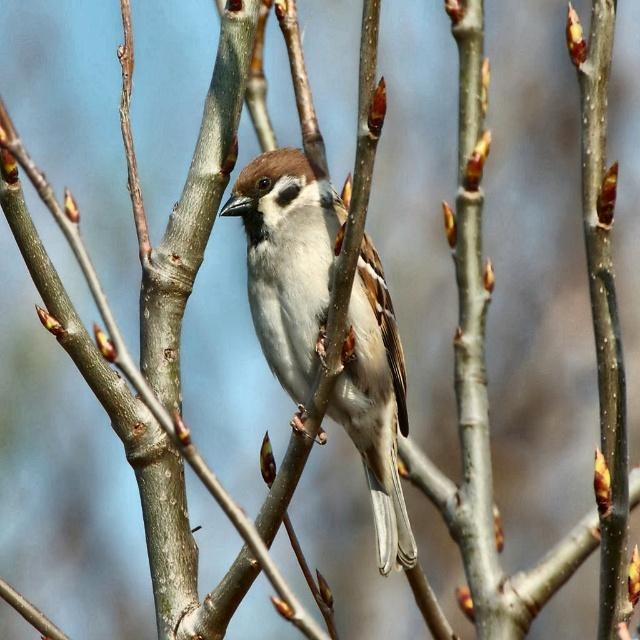

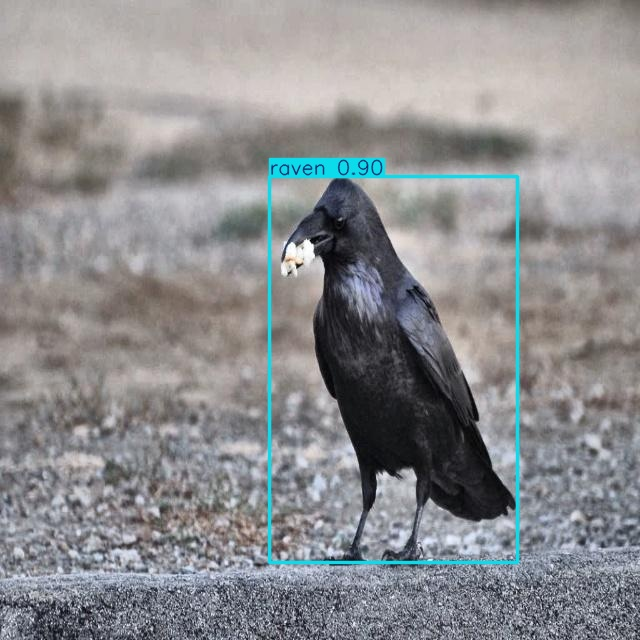

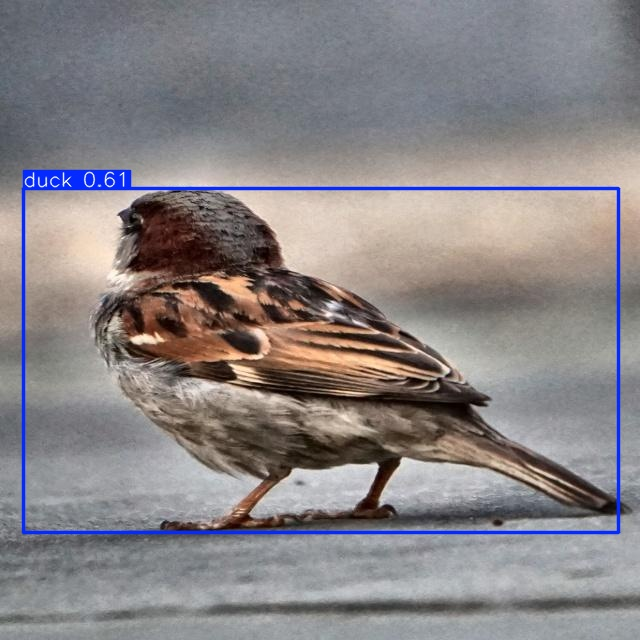

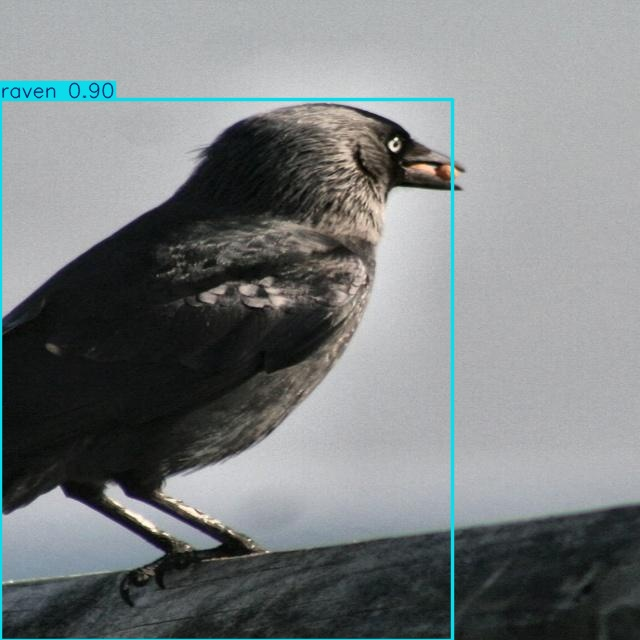

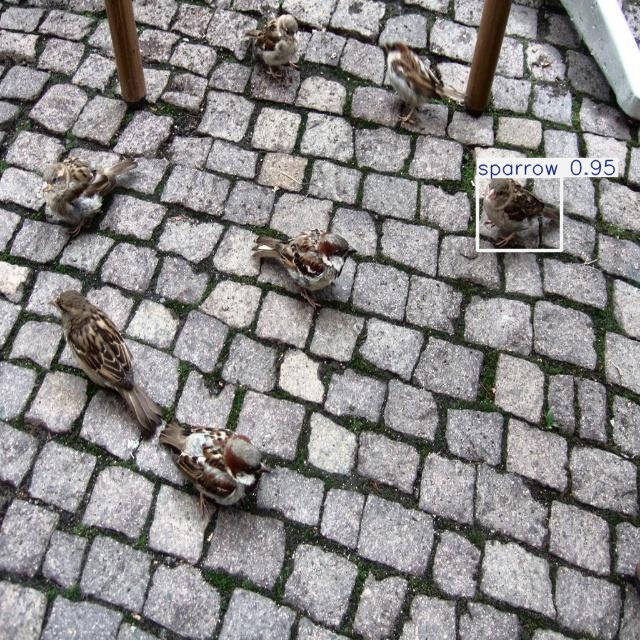

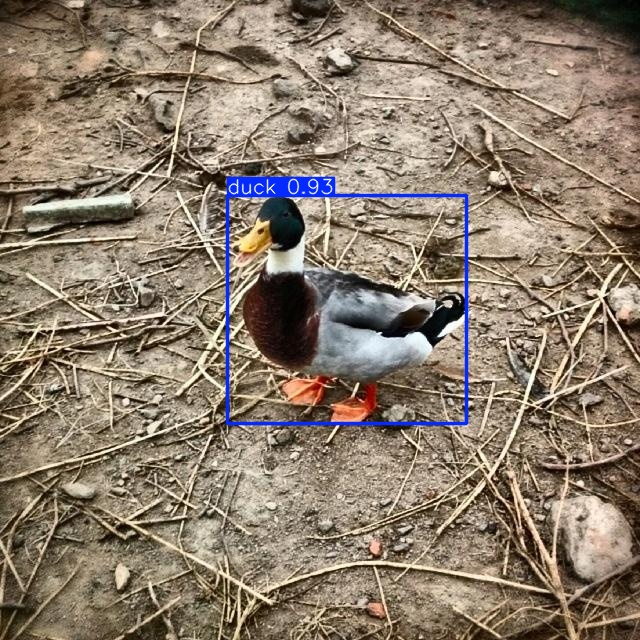

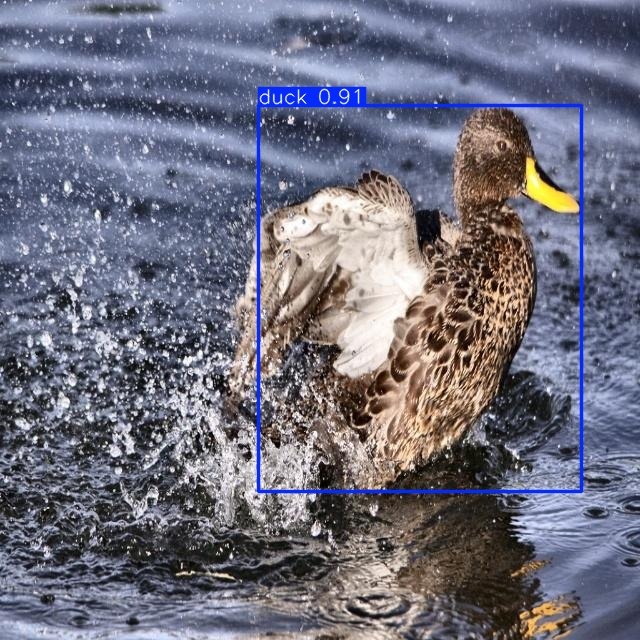

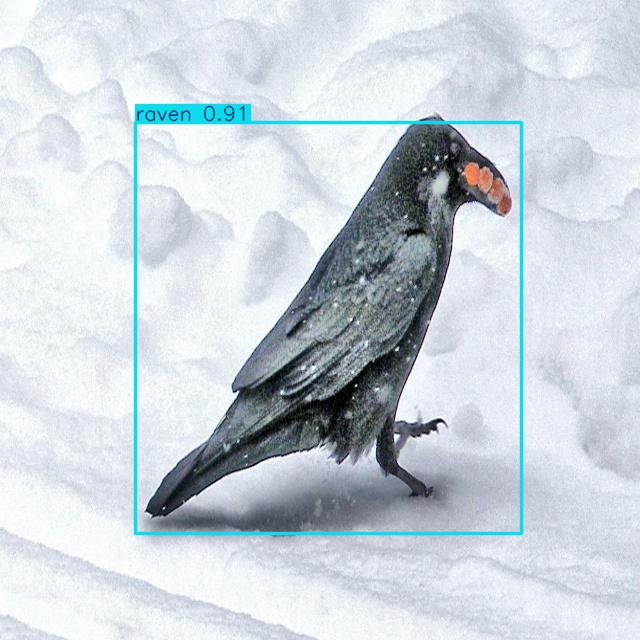

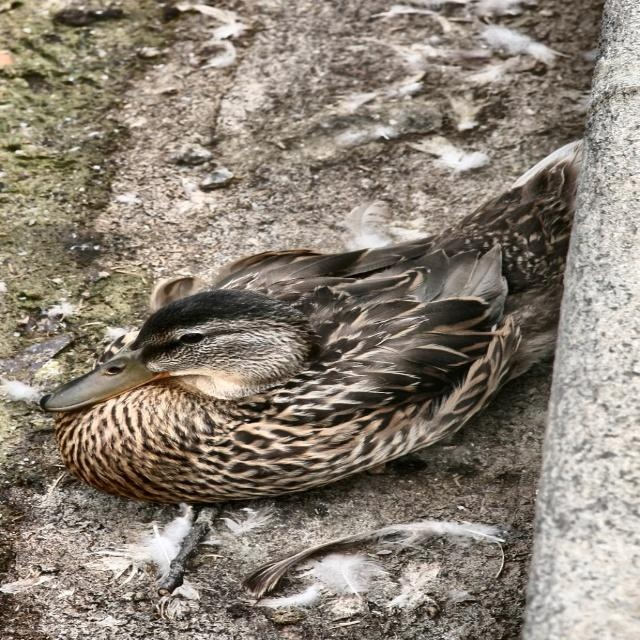

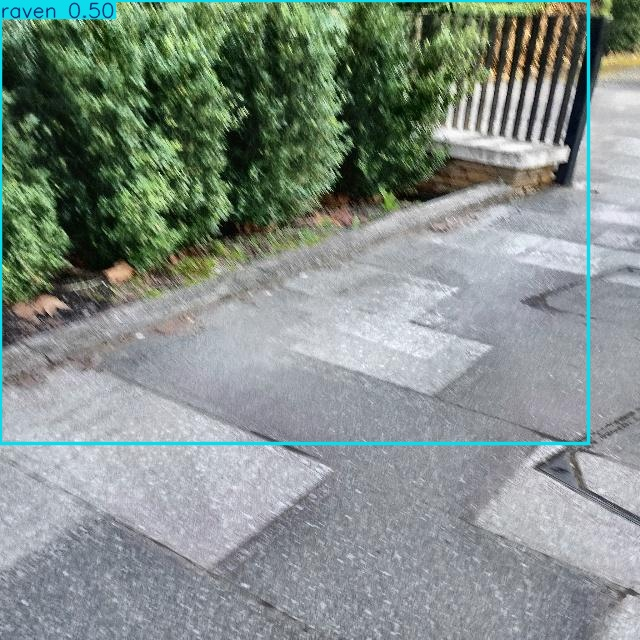

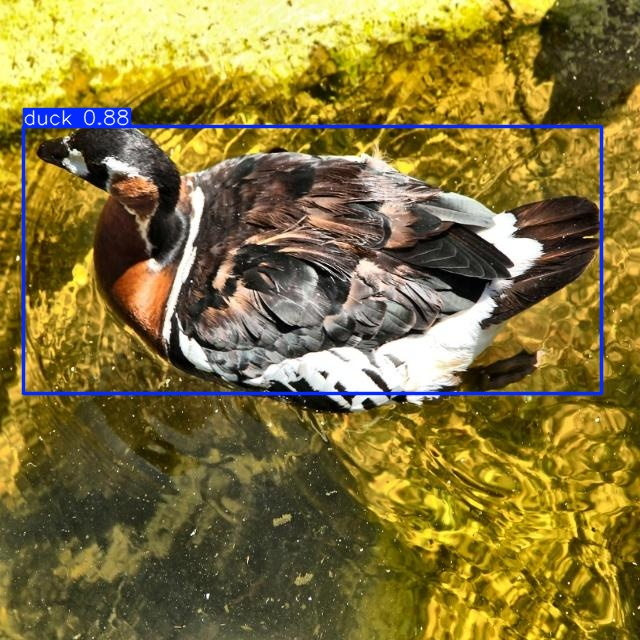

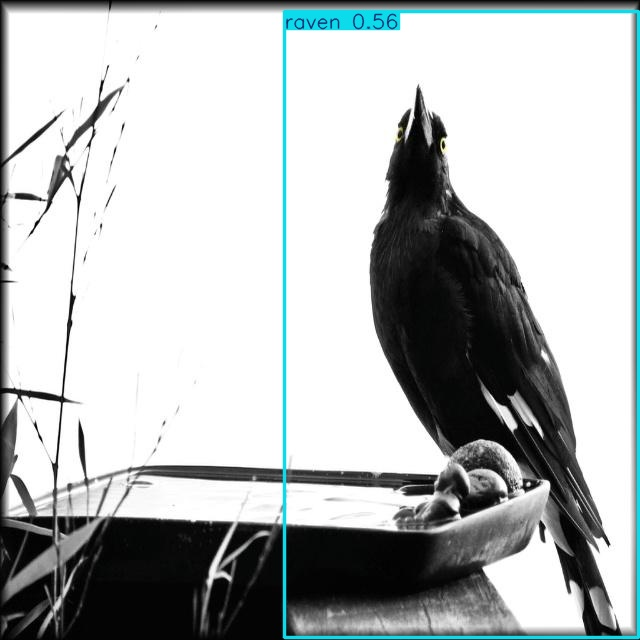

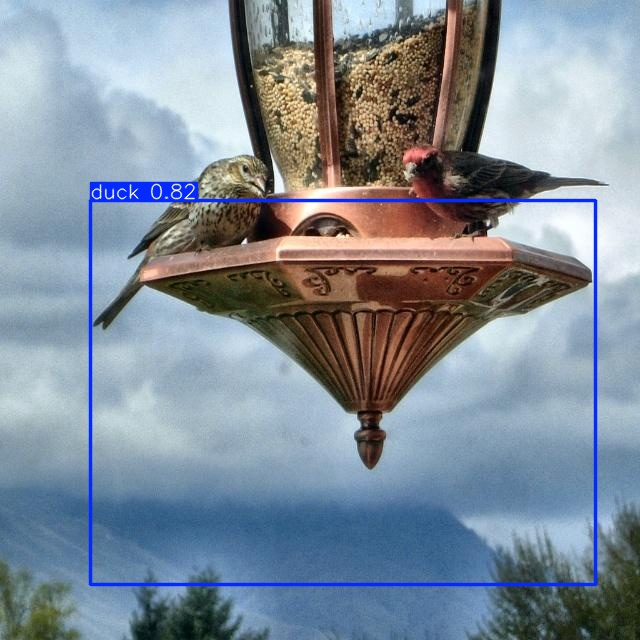

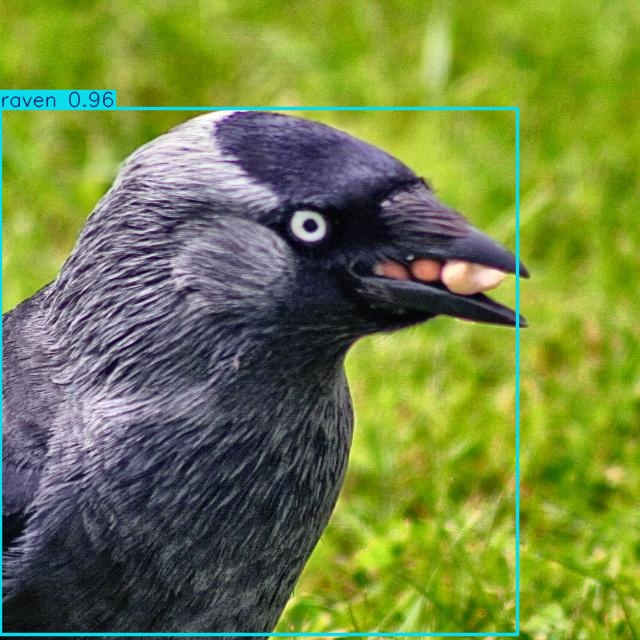

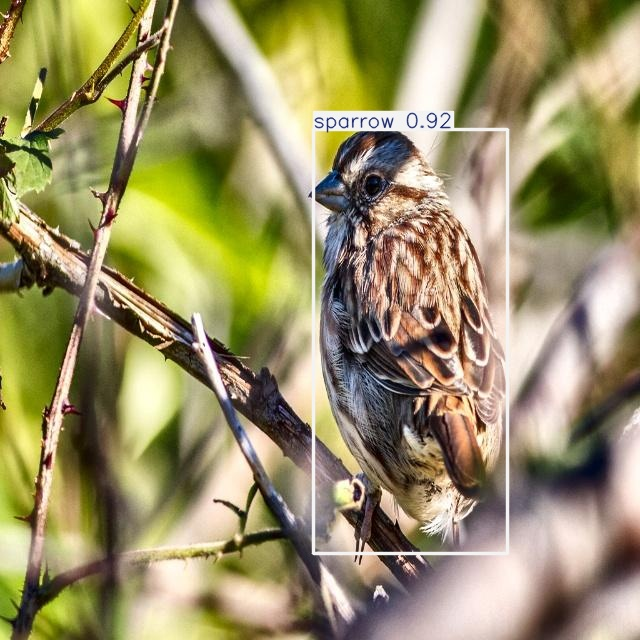

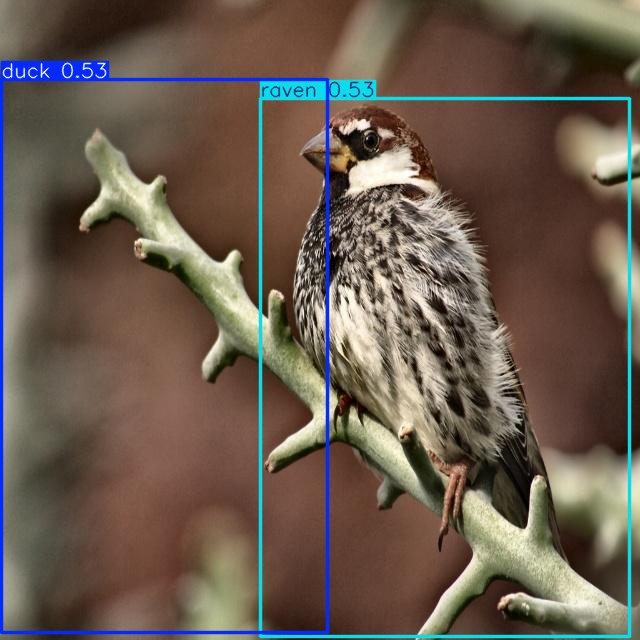

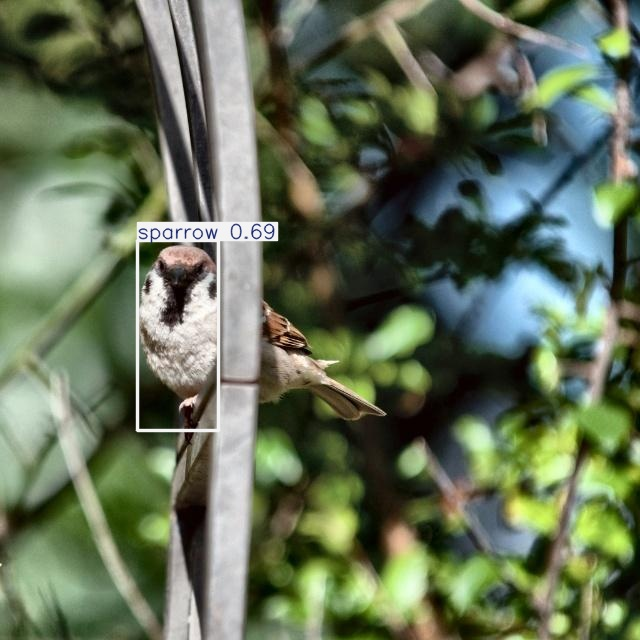

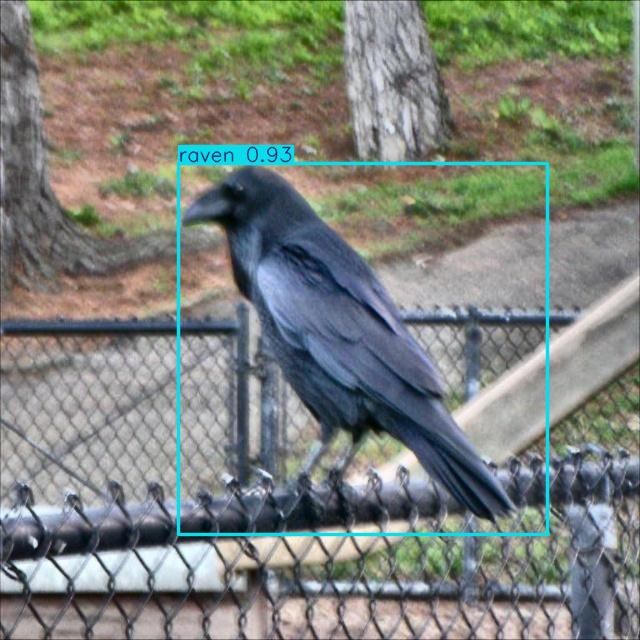

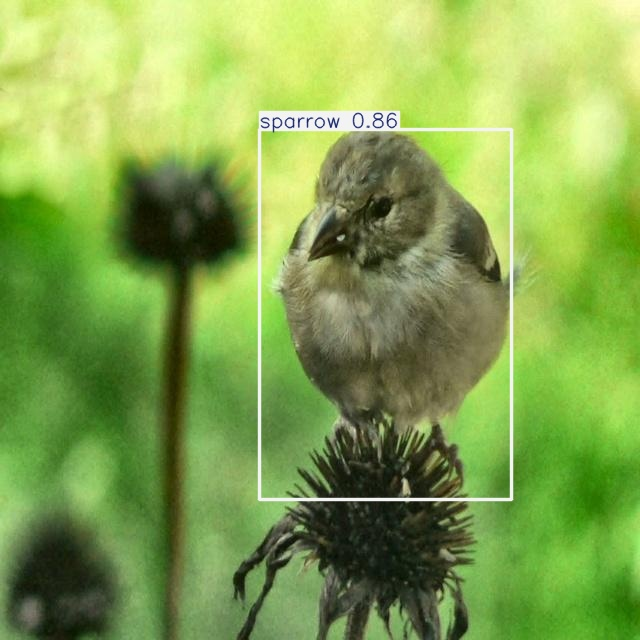

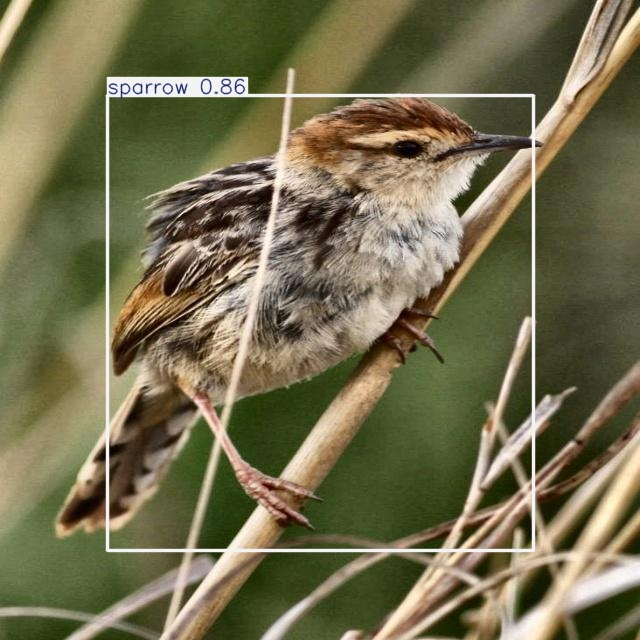

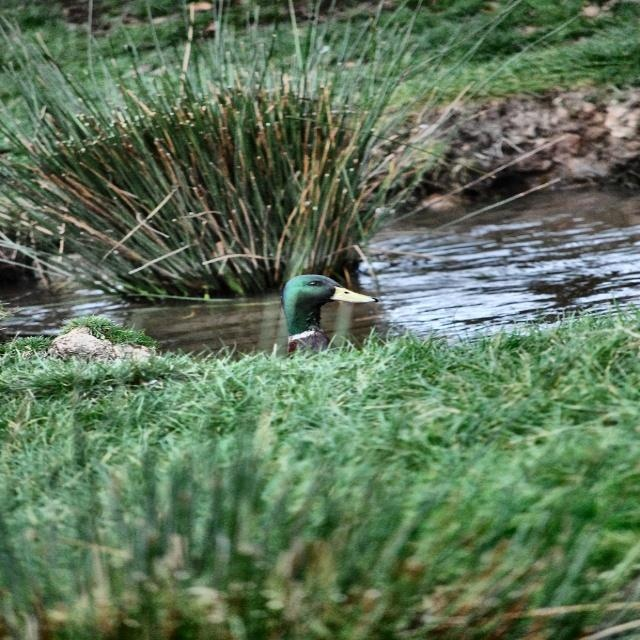

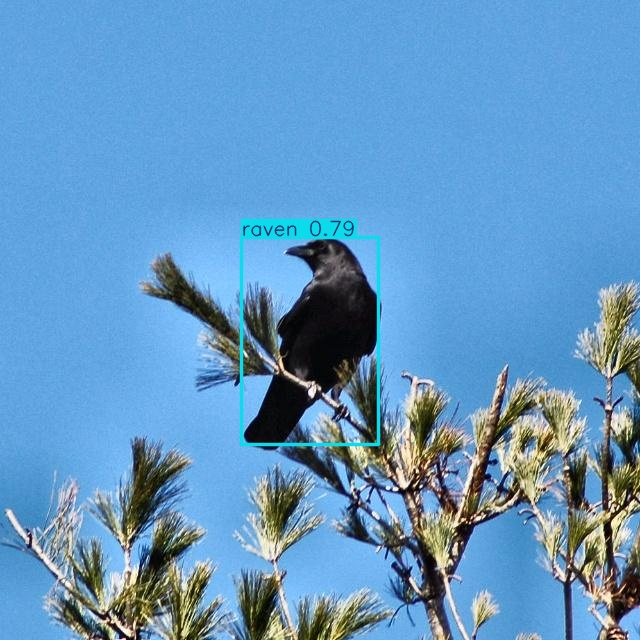

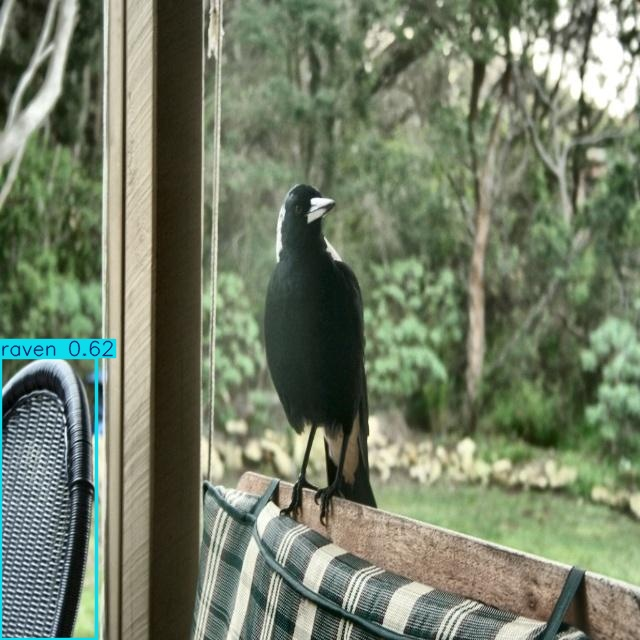

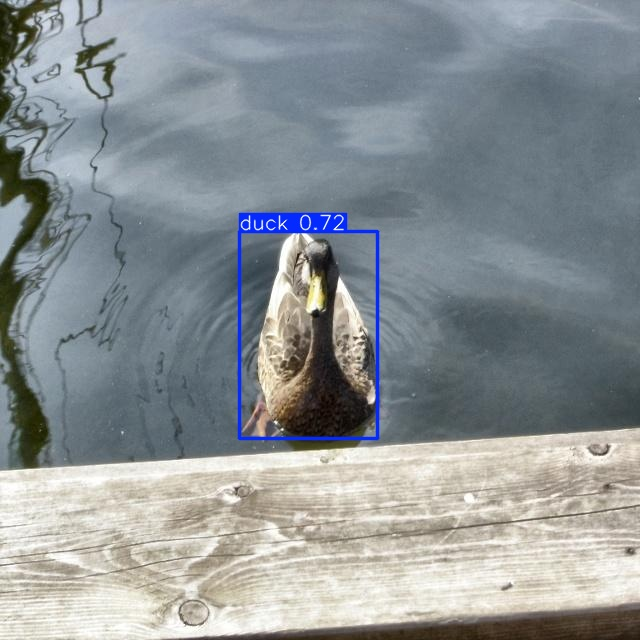

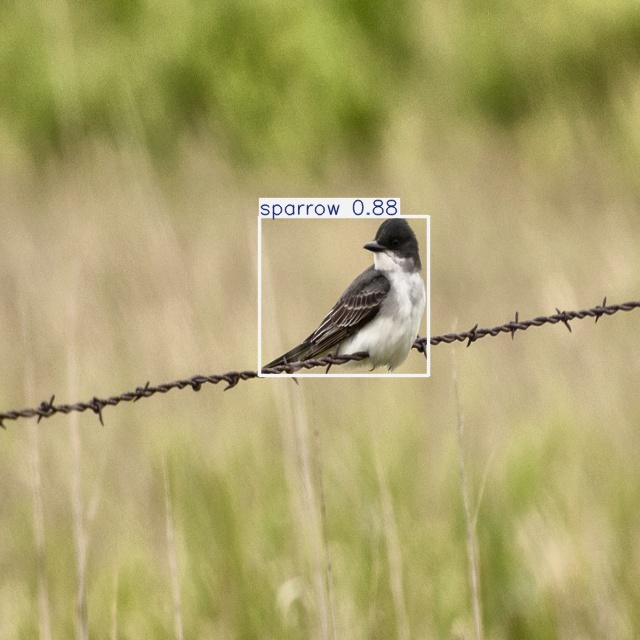

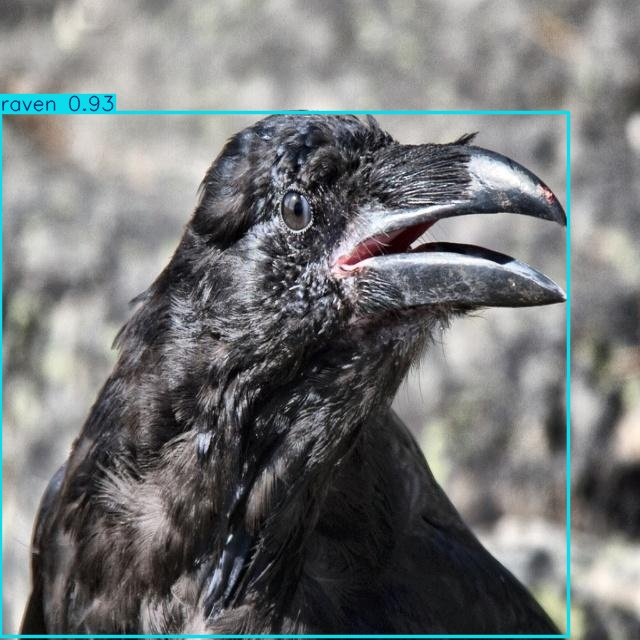

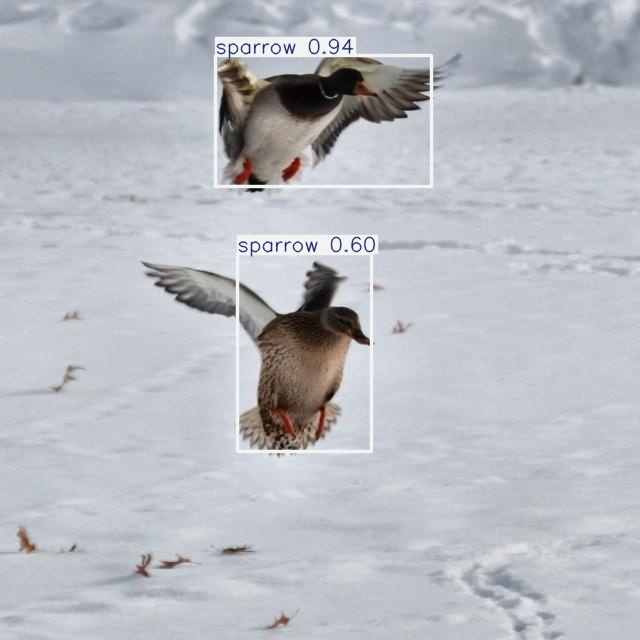

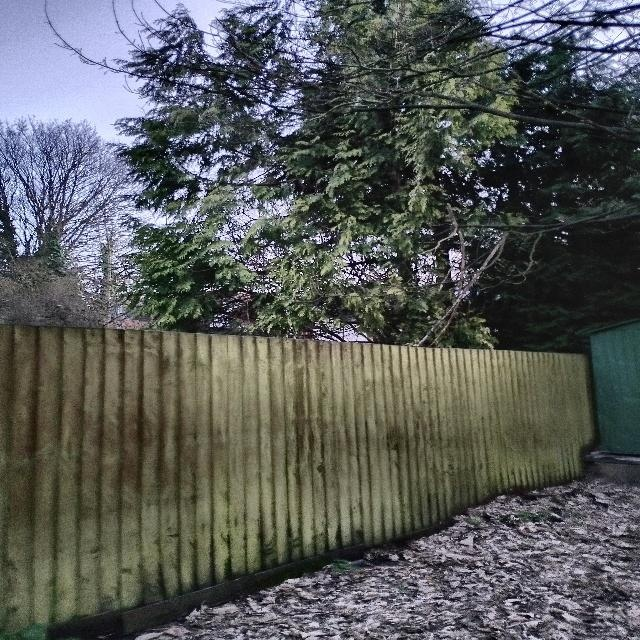

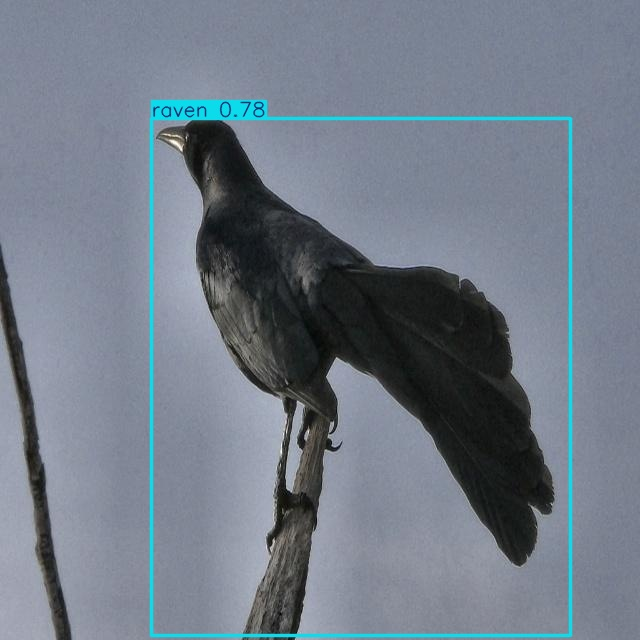

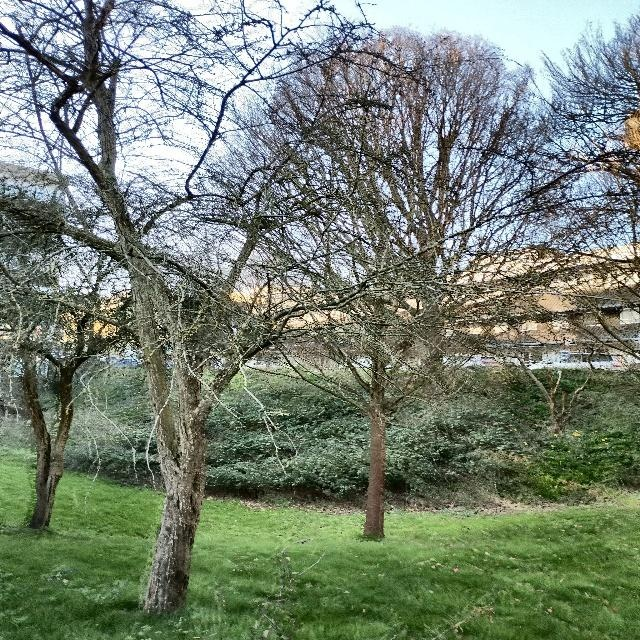

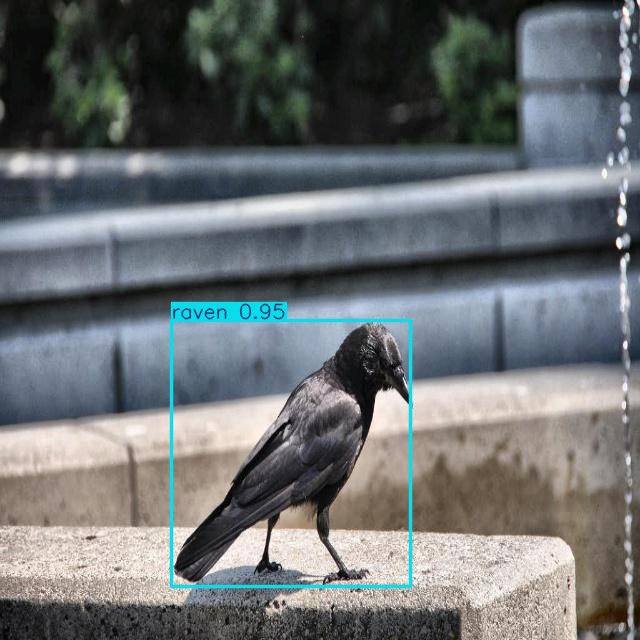

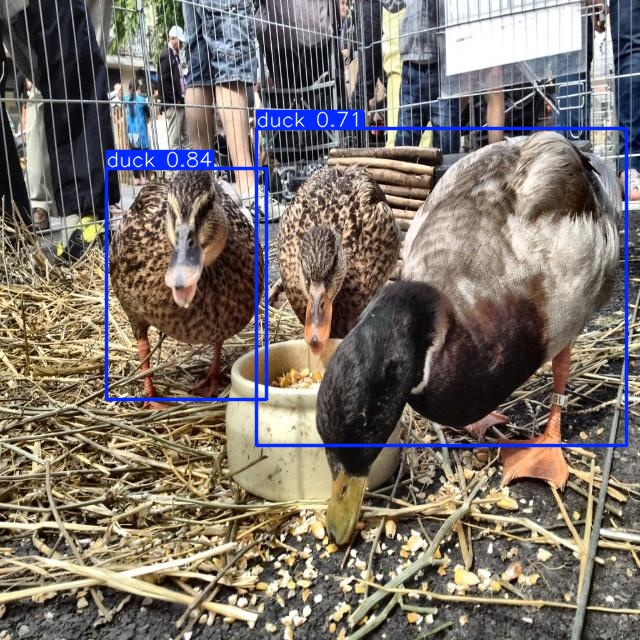

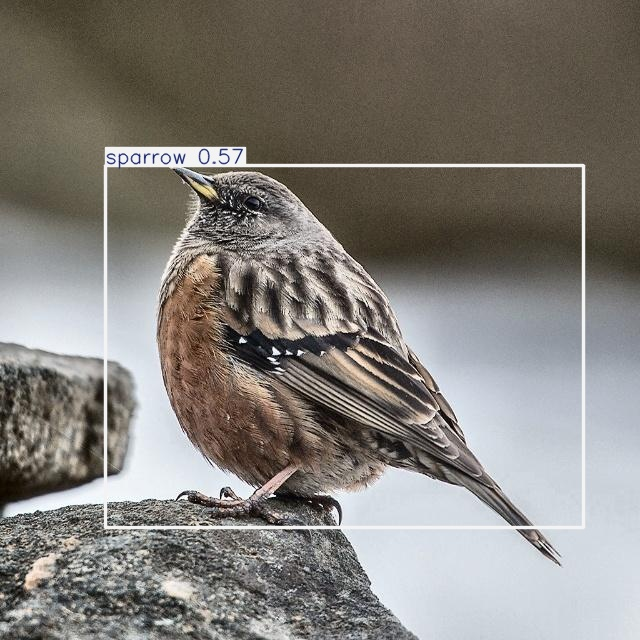

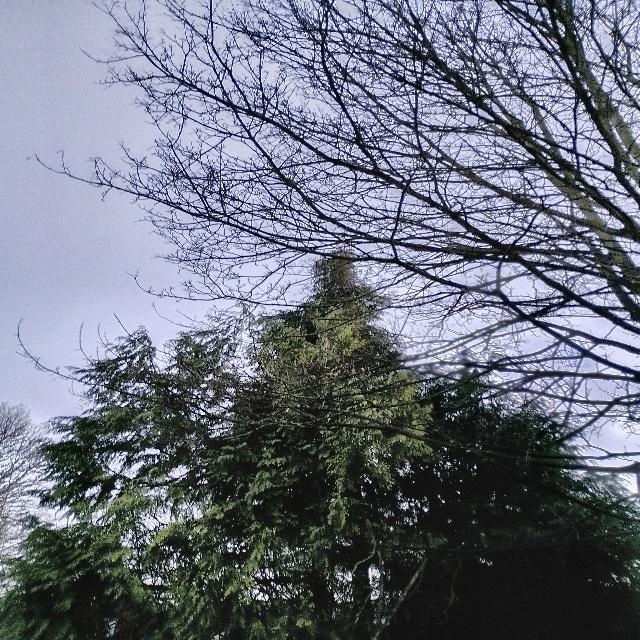

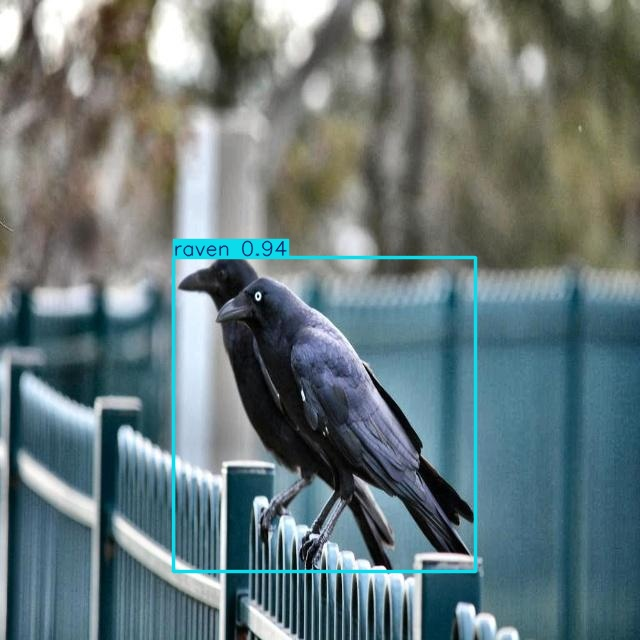

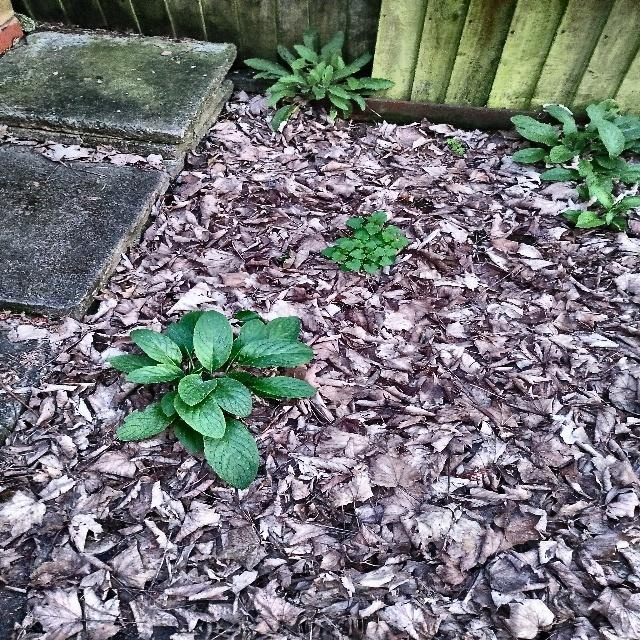

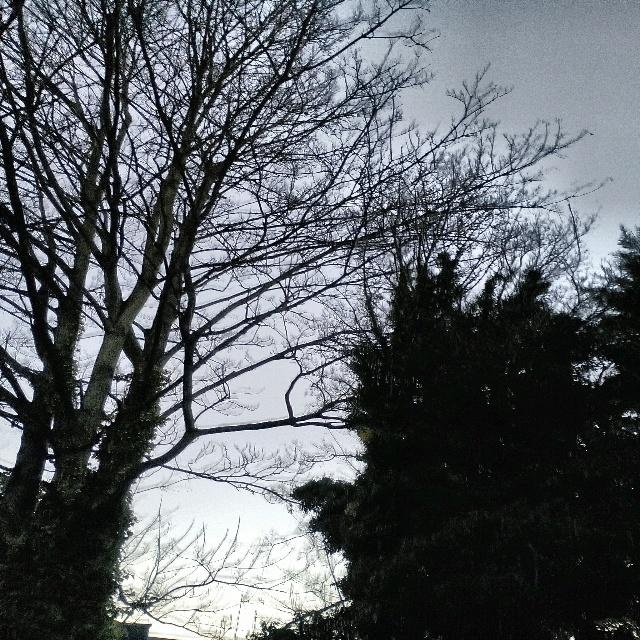

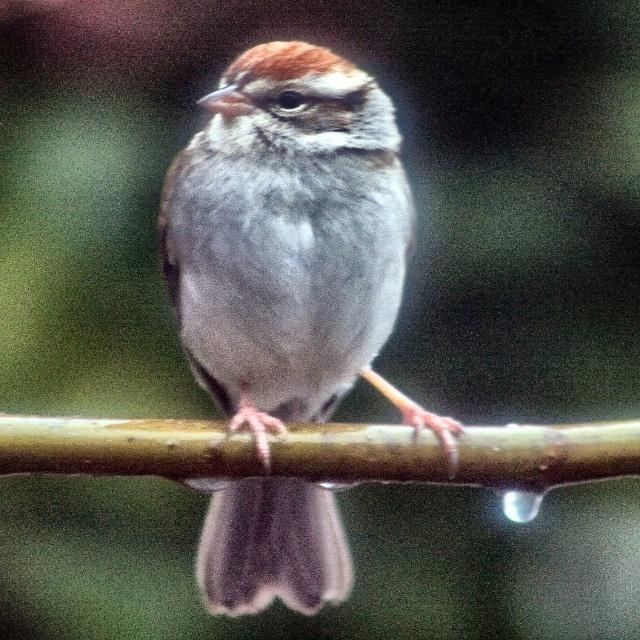

In [ ]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg'):
  display(Image(filename=image_path, height=600))
  print('\n')

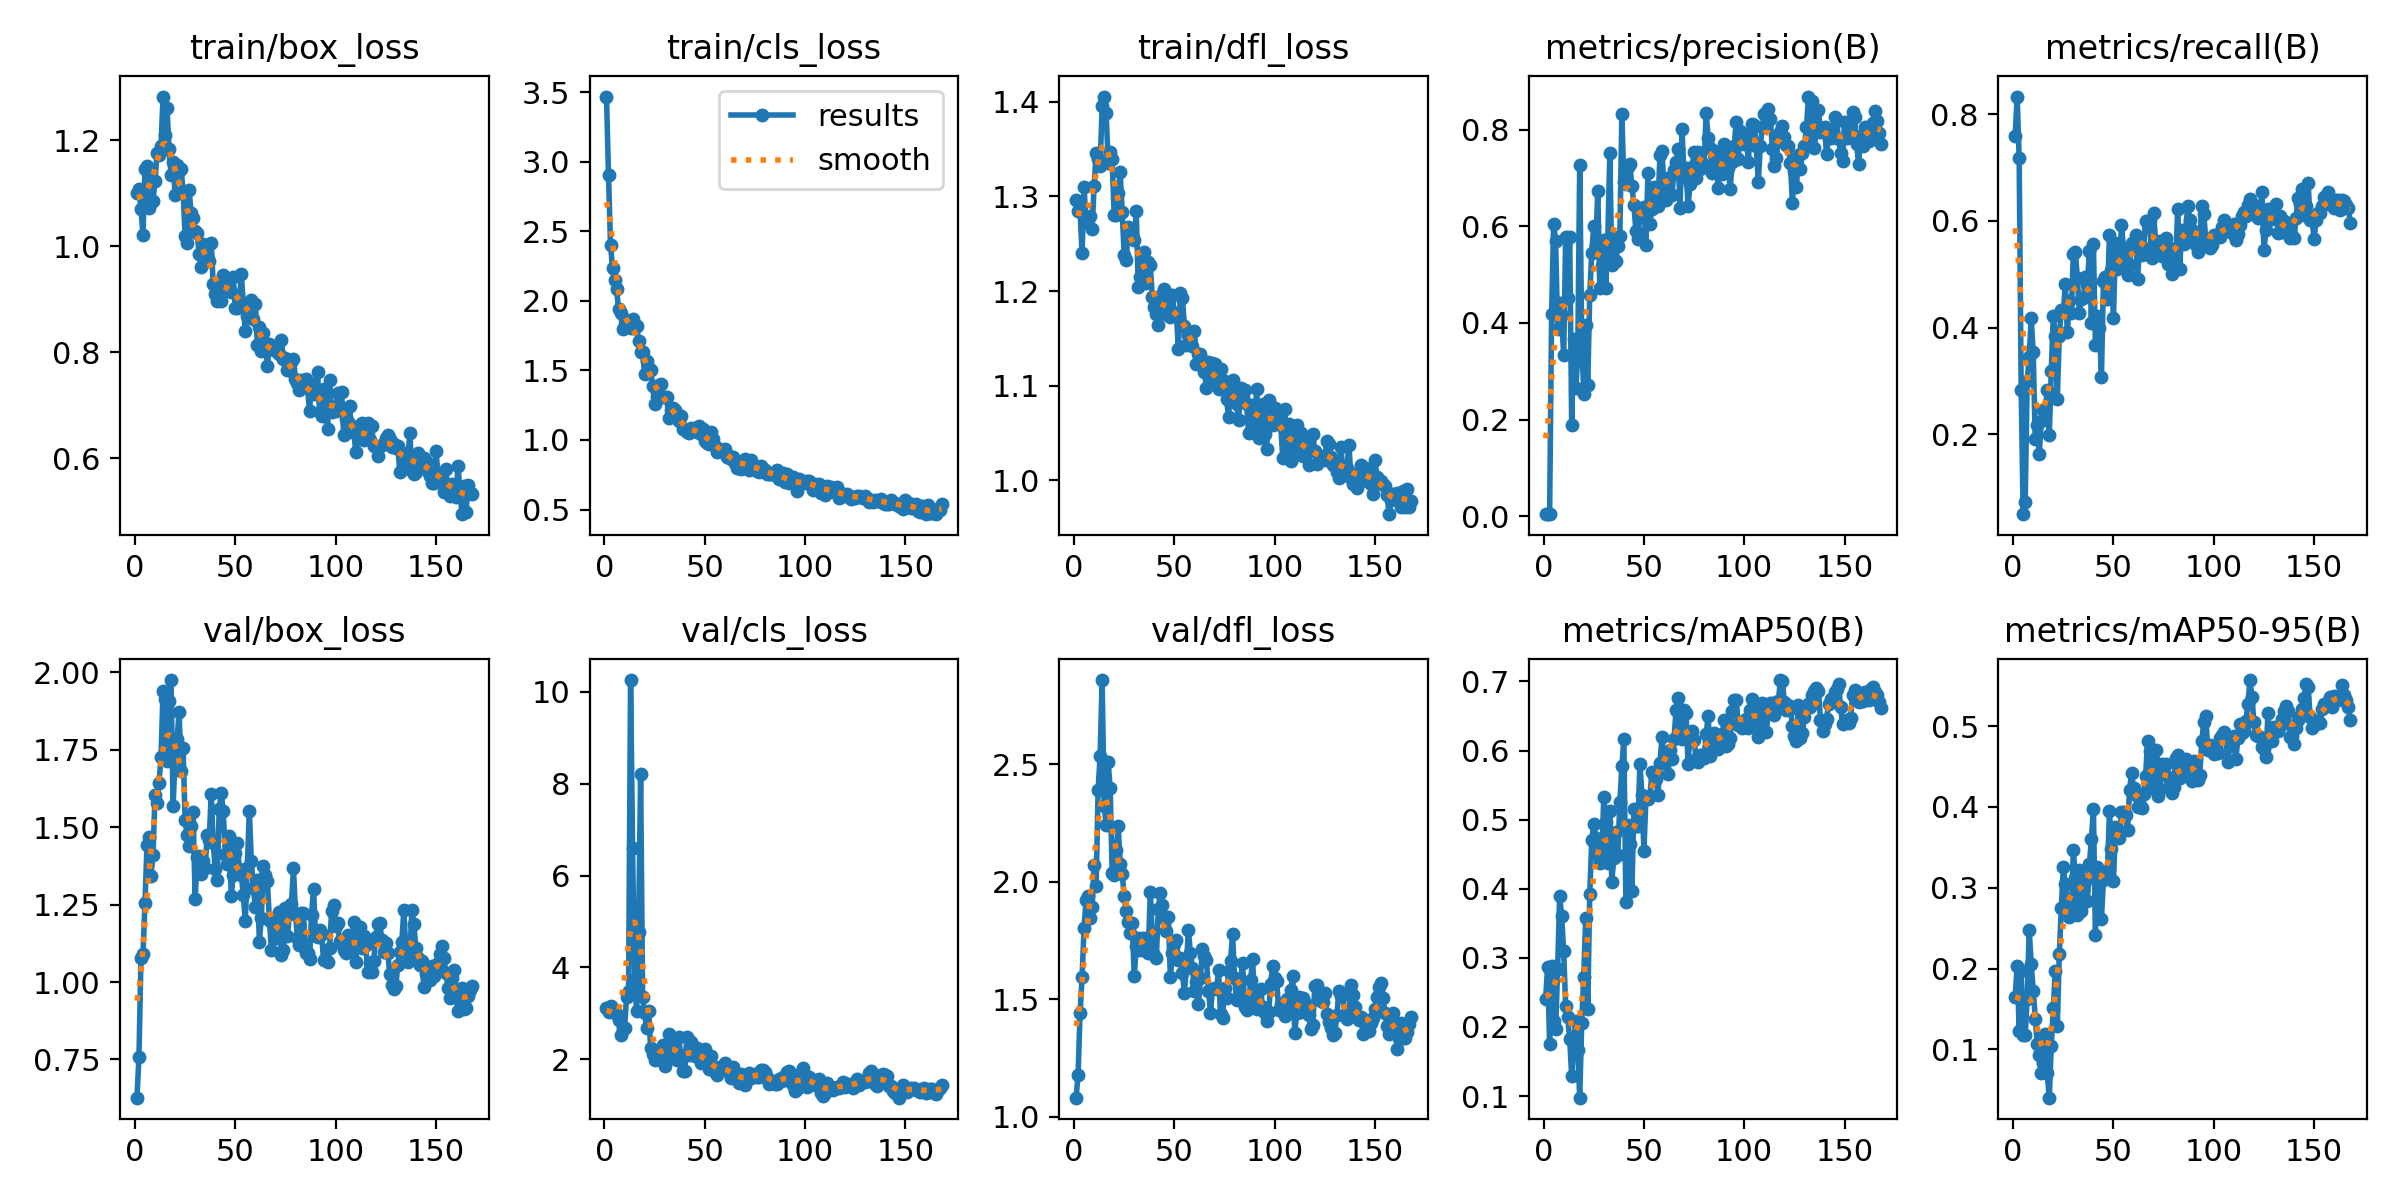

In [ ]:
Image(filename=f'/content/runs/detect/train/results.png', width=1000)

In [ ]:
# Create model folder to store model weights and train results
!mkdir /content/my_fourth_trained_model
!cp /content/runs/detect/train/weights/best.pt /content/my_fourth_trained_model/my_fourth_trained_model.pt
!cp -r /content/runs/detect/train /content/my_fourth_trained_model

# Zip into "my_model.zip"
%cd my_fourth_trained_model
!zip /content/my_fourth_trained_model.zip my_fourth_trained_model.pt
!zip -r /content/my_fourth_trained_model.zip train
%cd /content

/content/my_fourth_trained_model
  adding: my_fourth_trained_model.pt (deflated 10%)
  adding: train/ (stored 0%)
  adding: train/val_batch0_pred.jpg (deflated 5%)
  adding: train/results.csv (deflated 61%)
  adding: train/train_batch2.jpg (deflated 1%)
  adding: train/val_batch1_pred.jpg (deflated 6%)
  adding: train/results.png (deflated 6%)
  adding: train/weights/ (stored 0%)
  adding: train/weights/best.pt (deflated 10%)
  adding: train/weights/last.pt (deflated 10%)
  adding: train/labels.jpg (deflated 28%)
  adding: train/confusion_matrix.png (deflated 30%)
  adding: train/args.yaml (deflated 52%)
  adding: train/train_batch1.jpg (deflated 2%)
  adding: train/train_batch0.jpg (deflated 1%)
  adding: train/val_batch0_labels.jpg (deflated 5%)
  adding: train/val_batch1_labels.jpg (deflated 6%)
  adding: train/BoxP_curve.png (deflated 10%)
  adding: train/BoxPR_curve.png (deflated 15%)
  adding: train/BoxF1_curve.png (deflated 9%)
  adding: train/BoxR_curve.png (deflated 12%)
  add

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
# This takes forever for some reason, you can also just download the model from the sidebar
from google.colab import files

files.download('/content/my_fourth_trained_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>